In [1]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm
import json

In [11]:
def parse_log(log):
    if os.path.exists(log):
        with open(log, 'r') as f:
            lines = f.readlines()
        lines = [lines[-2].strip(), lines[-1].strip()]
        lines = ' '.join(lines)
        maps = lines.split('[')[1].split(']')[0].split(" ")
        maps = [float(m) for m in maps if m != '']
    return maps

In [4]:
# OralDelivery, SoftPalateLift, HyoidExercise, UESOpen, ThroatSwallow, ThroatTransport, LaryngealVestibuleClosure
actions = ["OralDelivery", "SoftPalateLift", "HyoidExercise", "UESOpen", "ThroatSwallow", "ThroatTransport", "LaryngealVestibuleClosure"]

In [18]:
best_root = '../outputs/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg'
best_results = {}
for action in actions:
    best_log = os.path.join(best_root, f"{action}.log")
    assert os.path.exists(best_log), f"Log file {best_log} does not exist."
    best_maps = parse_log(best_log)
    
    if not best_maps:
        print(f"No data found for {action}. Skipping...")
        continue

    best_results[action] = best_maps

# to dataframe
# reverse row and column
# row is action, column is tIoU threshold
df = pd.DataFrame(best_results).T
tIoU = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7]
df.columns = tIoU
df.index.name = 'Action'
# calculate mean AP
df['MeanAP'] = df.mean(axis=1)
# round to 2 decimal places
df = df.round(1)
df

,0.1,0.2,0.3,0.4,0.5,0.6,0.7,MeanAP
Action,,,,,,,,
OralDelivery,73.6,69.7,62.7,51.1,39.5,21.5,12.2,47.2
SoftPalateLift,86.4,84.7,84.6,82.9,74.5,67.8,46.2,75.3
HyoidExercise,88.0,87.5,82.6,67.1,37.0,23.4,6.6,56.0
UESOpen,85.9,85.9,85.5,85.2,85.0,83.6,77.8,84.1
ThroatSwallow,73.0,47.9,34.0,18.0,10.9,5.1,2.1,27.3
ThroatTransport,90.7,89.8,89.3,89.3,86.5,75.2,54.6,82.2
LaryngealVestibuleClosure,84.2,84.0,83.4,82.1,79.3,73.5,60.9,78.2


In [66]:
normal_kalman_root = '../outputs/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg_normalkalman_single_actions'
normal_kalman_results = {}
eps = [5, 10, 15, 18, 20, 22, 25, 28, 30]
# actions/epochs/ap(tIoU)
for action in actions:
    normal_kalman_results[action] = {}

    normal_kalman_log = os.path.join(normal_kalman_root, f"eval_0.7_{action}.log")
    assert os.path.exists(normal_kalman_log), f"Log file {normal_kalman_log} does not exist."
    normal_kalman_maps = parse_log(normal_kalman_log)
    
    for ep in eps:
        log = os.path.join(normal_kalman_root, f"eval_0.7_{action}_ep{ep}.log")
        if os.path.exists(log):
            maps = parse_log(log)
            if maps:
                normal_kalman_results[action][f'ep{ep}'] = np.mean(maps)

    if not normal_kalman_maps:
        print(f"No data found for {action}. Skipping...")
        continue

    normal_kalman_results[action]['ep34'] = np.mean(normal_kalman_maps)

    

# normal_kalman_results

# # to dataframe
# row is action, epoch, column is tIoU threshold
normal_kalman_df = pd.DataFrame(normal_kalman_results).T
normal_kalman_df

,ep5,ep10,ep15,ep18,ep20,ep22,ep25,ep28,ep30,ep34
OralDelivery,43.593598,45.049454,40.869278,40.459550,40.912164,40.719777,39.881439,38.769236,38.624572,37.987424
SoftPalateLift,70.545914,65.699821,69.469423,72.791007,74.502797,75.100028,75.628724,75.130188,74.688607,74.610338
HyoidExercise,42.328437,51.390090,51.808709,52.816763,53.064516,53.483872,53.429802,52.843366,52.962254,53.544157
UESOpen,69.322581,79.821969,82.121753,82.962531,82.811028,82.736569,82.248473,82.357003,82.254408,82.130180
ThroatSwallow,24.000115,27.654231,27.072827,26.298326,25.948769,25.182673,24.790938,24.484649,24.295630,24.181274
ThroatTransport,58.130053,72.402909,76.482823,77.840652,78.713677,79.377763,79.257288,78.750415,78.751315,78.228194
LaryngealVestibuleClosure,72.343985,75.609390,77.548249,78.369001,78.162304,78.404629,78.432207,78.851991,78.662319,78.970485


In [53]:
np.mean(normal_kalman_df['best'].tolist())

61.37886455653062

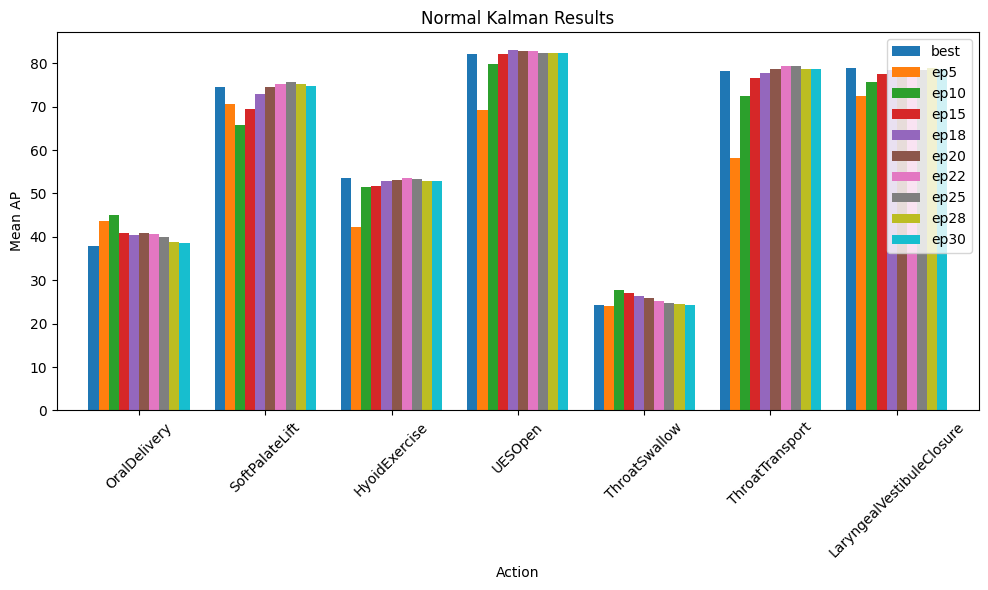

In [57]:
# draw table to plot (except the best column)
# normal_kalman_df = normal_kalman_df.drop(columns=['best'])

from matplotlib import pyplot as plt
fig, ax = plt.subplots(figsize=(10, 6))
normal_kalman_df.plot(kind='bar', ax=ax, width=0.8)
ax.set_title('Normal Kalman Results')
ax.set_xlabel('Action')
ax.set_ylabel('Mean AP')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [72]:
# select the best results and get the corresponding epoch
best_epochs = {}
for action in actions:
    if action in normal_kalman_results:
        best_epoch = max(normal_kalman_results[action].keys(), key=lambda x: normal_kalman_results[action][x])
        best_epochs[action] = best_epoch
    else:
        best_epochs[action] = 'N/A'

best_epochs_df = pd.DataFrame.from_dict(best_epochs, orient='index', columns=['Best Epoch'])
best_epochs_df

,Best Epoch
OralDelivery,ep10
SoftPalateLift,ep25
HyoidExercise,ep34
UESOpen,ep18
ThroatSwallow,ep10
ThroatTransport,ep22
LaryngealVestibuleClosure,ep34


In [73]:
best_epochs

{'OralDelivery': 'ep10',
 'SoftPalateLift': 'ep25',
 'HyoidExercise': 'ep34',
 'UESOpen': 'ep18',
 'ThroatSwallow': 'ep10',
 'ThroatTransport': 'ep22',
 'LaryngealVestibuleClosure': 'ep34'}

In [75]:
for action in actions:
    if action not in ['OralDelivery', 'ThroatSwallow']:
        best_epochs[action] = 'best'
best_epochs

{'OralDelivery': 'ep10',
 'SoftPalateLift': 'best',
 'HyoidExercise': 'best',
 'UESOpen': 'best',
 'ThroatSwallow': 'ep10',
 'ThroatTransport': 'best',
 'LaryngealVestibuleClosure': 'best'}

In [76]:
# create a directory and make soft link to the best results
import shutil
normal_kalman_ckpts_root = '/mnt/cephfs/dataset/swallow_ckpt/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg_normalkalman'
output_root = '/mnt/cephfs/dataset/swallow_ckpt/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg_normalkalman_best'
if not os.path.exists(output_root):
    os.makedirs(output_root)
else:
    shutil.rmtree(output_root)
    os.makedirs(output_root)
for action, epoch in best_epochs.items():
    # try to get action directory
    action_dirs = os.listdir(normal_kalman_ckpts_root)
    action_dir = None
    for ad in action_dirs:
        if action in ad:
            action_dir = ad
            break
    if action_dir is None:
        print(f"Action {action} not found in {normal_kalman_ckpts_root}. Skipping...")
        continue
    if epoch != 'N/A':
        ckpts = os.listdir(os.path.join(normal_kalman_ckpts_root, action_dir))
        ckpts = [c for c in ckpts if c.endswith('.tar')]
        if epoch.startswith('ep'): # not the best epoch
            epoch = epoch[2:]
            epoch = int(epoch)
            epoch = f"{epoch:03d}"  # format to 3 digits
            # try to get the epoch checkpoint
            ckpt = [c for c in ckpts if f"{epoch}" in c][0]
            src = os.path.join(normal_kalman_ckpts_root, action_dir, ckpt) 
        else:  # is the best epoch
            ckpt = sorted(ckpts, key=lambda x: float(x.split(".pth.tar")[0].split("_")[-1]), reverse=True)[0]
            src = os.path.join(normal_kalman_ckpts_root, action_dir, ckpt)
        dst = os.path.join(output_root, action_dir, ckpt)
        # get src original path if it is a symlink
        if os.path.islink(src):
            src = os.readlink(src)
        if not os.path.exists(os.path.dirname(dst)):
            os.makedirs(os.path.dirname(dst))
        if os.path.exists(src) and not os.path.exists(dst) and not os.path.islink(dst):
            os.symlink(src, dst)
            print(f"Created symlink for {action} at {dst} from {src}")
        elif os.path.exists(src):
            print(f"Symlink for {action} already exists at {dst}. Skipping...")
        else:
            print(f"[Warning] Source file {src} does not exist. Skipping...")
    else:
        print(f"No best epoch for {action}. Skipping...")

Created symlink for OralDelivery at /mnt/cephfs/dataset/swallow_ckpt/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg_normalkalman_best/mamba_swallow_i3d_secondstage_2tower_crossmamba_l3_ep30_acu4_loadheatmap_channelagg_normalkalman_vw0.7_heatmap_secondstage_videomamba_l3_avgtoken_ep45_sigma4_hid576_normalkalman_OralDelivery_load_heatmap_16_0.0001/epoch_010_0.84334.pth.tar from /mnt/cephfs/dataset/swallow_ckpt/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg_normalkalman/mamba_swallow_i3d_secondstage_2tower_crossmamba_l3_ep30_acu4_loadheatmap_channelagg_normalkalman_vw0.7_heatmap_secondstage_videomamba_l3_avgtoken_ep45_sigma4_hid576_normalkalman_OralDelivery_load_heatmap_16_0.0001/epoch_010_0.84334.pth.tar
Created symlink for SoftPalateLift at /mnt/cephfs/dataset/swallow_ckpt/2tower_crossmamba_3layer_ep30_vw0.7_heatmap_channelagg_normalkalman_best/mamba_swallow_i3d_secondstage_2tower_crossmamba_l3_ep30_acu4_loadheatmap_channelagg_normalkalman_vw0.7_heatmap_secondstage_video

In [63]:
results={'average_mAP': 41.772709134165055, 'mAP@0.1': 57.56581947128075, 'mAP@0.2': 56.42319152896772, 'mAP@0.3': 55.75059499328716, 'mAP@0.4': 50.10889338581481, 'mAP@0.5': 38.6554400854322, 'mAP@0.6': 20.910606333073332, 'mAP@0.7': 12.99441814129941}
# results = {k: f"{v:.1f}" for k, v in results.items()}
# to dataframe
results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Value'])
results_df.T

,average_mAP,mAP@0.1,mAP@0.2,mAP@0.3,mAP@0.4,mAP@0.5,mAP@0.6,mAP@0.7
Value,41.772709,57.565819,56.423192,55.750595,50.108893,38.65544,20.910606,12.994418
